# Global population and Net migration 
<img src="https://blog.dhsprogram.com/wp-content/uploads/Ruchaneek_Adobe-Stock-scaled.jpeg" alt="Alt Text" width="500"/> 

In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated", category=FutureWarning)


In [166]:
df= pd.read_csv('/kaggle/input/global-population-and-migration-dataset/world_pop_mig_186_countries.csv')
df.head(5)

,country,year,population,netMigration,population_in_millions
0,Afghanistan,2023,42239854.0,-65846.0,42
1,Afghanistan,2022,41128771.0,-65846.0,41
2,Afghanistan,2021,40099462.0,-183672.0,40
3,Afghanistan,2020,38972230.0,166821.0,38
4,Afghanistan,2019,37769499.0,-8082.0,37


In [167]:
df.dtypes

country                    object
year                        int64
population                float64
netMigration              float64
population_in_millions      int64
dtype: object

In [168]:
df.isna().sum()

country                   0
year                      0
population                0
netMigration              0
population_in_millions    0
dtype: int64

In [169]:
df.describe()

,year,population,netMigration,population_in_millions
count,11904.000000,1.190400e+04,1.190400e+04,11904.000000
mean,1991.500000,2.703863e+07,7.482505e+02,26.618868
std,18.473729,1.128305e+08,1.621035e+05,112.812944
min,1960.000000,2.646000e+03,-6.673580e+06,0.000000
25%,1975.750000,5.973292e+05,-1.325250e+04,0.000000
50%,1991.500000,4.342186e+06,-4.840000e+02,4.000000
75%,2007.250000,1.333759e+07,5.505500e+03,13.000000
max,2023.000000,1.428628e+09,3.366387e+06,1428.000000


# <span style="color:Bold Black">Lets look at the country with the highest net migration in 2023</span>


In [170]:
top=df[df['year']==2023].groupby('country')['netMigration'].agg(['sum']).sort_values(by='sum',ascending=False).head(10)
top=top.reset_index()
top.head(10)


,country,sum
0,Ukraine,1784718.0
1,United States,999700.0
2,Syrian Arab Republic,757103.0
3,Canada,249746.0
4,United Kingdom,165790.0
5,Germany,155751.0
6,Australia,139991.0
7,Japan,99994.0
8,France,67761.0
9,Italy,58496.0


# Highest number of net migration in the year 2023

The net migration data for 2023 reveals a significant influx of people into the listed countries, with Ukraine experiencing the largest positive net migration of 1,784,718, likely influenced by ongoing conflicts and displacement. The United States follows closely with 999,700, reflecting its status as a major destination for migrants seeking better economic opportunities, safety, and political stability. Other countries with substantial positive net migration include the Syrian Arab Republic (757,103), likely due to people seeking refuge from ongoing conflict, and Canada (249,746), which is known for its welcoming immigration policies. The United Kingdom (165,790), Germany (155,751), and Australia (139,991) also show significant positive net migration, driven by factors such as economic opportunities, better quality of life, and political stability. Japan (99,994) and France (67,761) report moderate net migration, with Italy (58,496) seeing the lowest in this group. This trend suggests that these countries remain attractive to migrants, whether for economic, social, or political reasons, contributing to demographic and labor force changes in these regions.


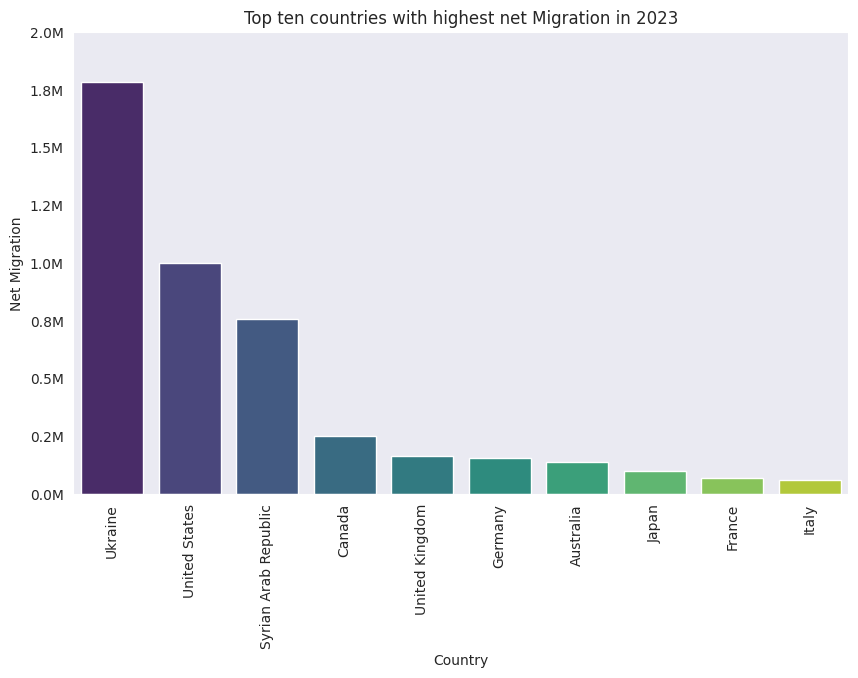

In [191]:
import matplotlib.ticker as mtick

sns.set_style('dark')

plt.figure(figsize=(10,6))
t=sns.barplot(data=top,x='country',y='sum',palette='viridis')
plt.xticks(rotation=90)
t.set(xlabel='Country',ylabel='Net Migration',title='Top ten countries with highest net Migration in 2023')
current_ticks = plt.gca().get_yticks()
plt.yticks(current_ticks, [f'{x/1e6:.1f}M' for x in current_ticks])
plt.show()

# Highest Net out migration in 2023


In [172]:
low=df[df['year']==2023].groupby('country')['netMigration'].agg(['sum']).sort_values(by='sum',ascending=True).head(10)
low=low.reset_index()
low.head(10)

,country,sum
0,Poland,-910475.0
1,India,-486136.0
2,China,-310220.0
3,Bangladesh,-309977.0
4,Romania,-254616.0
5,Lebanon,-177331.0
6,Colombia,-175051.0
7,Pakistan,-165988.0
8,Jordan,-157392.0
9,Hungary,-156677.0


**The net migration data for the year 2023 shows that the countries listed have experienced significant negative net migration. This indicates that more people have left these countries than entered them. For example, Poland stands out with the largest negative net migration of -910,475, followed by India with -486,136 and China with -310,220. Other countries like Bangladesh (-309,977), Romania (-254,616), and Lebanon (-177,331) also show substantial emigration. This suggests a trend where people are likely leaving these countries for better economic opportunities, safety, or social conditions elsewhere. The large outflows of people from countries like Poland and India may reflect high levels of labor migration or economic factors prompting individuals to seek opportunities abroad. This pattern of negative net migration could have significant socio-economic implications for these countries, particularly in terms of labor force shortages, demographic shifts, and potential long-term impacts on their economies and societies.**

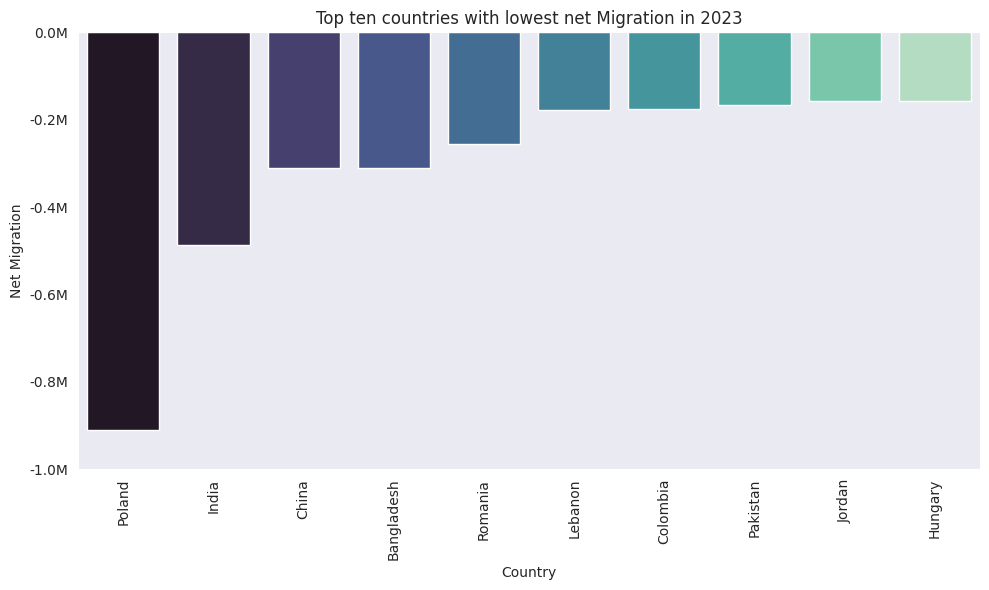

In [190]:
import matplotlib.ticker as mtick

sns.set_style('dark')

plt.figure(figsize=(10,6))
t=sns.barplot(data=low,x='country',y='sum',palette='mako')
plt.xticks(rotation=90)
t.set(xlabel='Country',ylabel='Net Migration',title='Top ten countries with lowest net Migration in 2023')
current_ticks = plt.gca().get_yticks()
plt.yticks(current_ticks, [f'{x/1e6:.1f}M' for x in current_ticks])
plt.tight_layout() 
plt.show()

In [174]:
df[df['netMigration']==df['netMigration'].max()]

,country,year,population,netMigration,population_in_millions
8705,Poland,2022,36821749.0,3366387.0,36


### Poland: Net Migration in 2022

- **2022**: Poland experienced a significant **net migration inflow** of **3,366,387** people, which marked a notable increase in its population. This large migration inflow can be attributed to the **influx of refugees from Ukraine** following the Russian invasion in 2022. Poland became a key destination for displaced Ukrainians seeking refuge from the ongoing conflict, which dramatically influenced the country's migration figures.

## Summary
Poland's data for 2022 highlights the profound impact of the geopolitical crisis in Eastern Europe, with millions of refugees entering the country. The sharp increase in population underscores Poland's role as a major host nation during the humanitarian crisis in the region.


In [175]:
df['population'].corr(df['netMigration'])

-0.08919536294669217

# We will be looking mainly at the data of Nepal

In [176]:
Nepal=df[df['country']=='Nepal']

In [177]:
nepal=df[df['country']=='Nepal'].groupby('year')['netMigration'].agg(['sum'])
nepal.sort_values(by='sum',ascending=False).head(5)

,sum
year,
2020,306664.0
2021,296541.0
1992,84106.0
1991,17056.0
1980,5084.0


Text(0, 0.5, 'Net Migration')

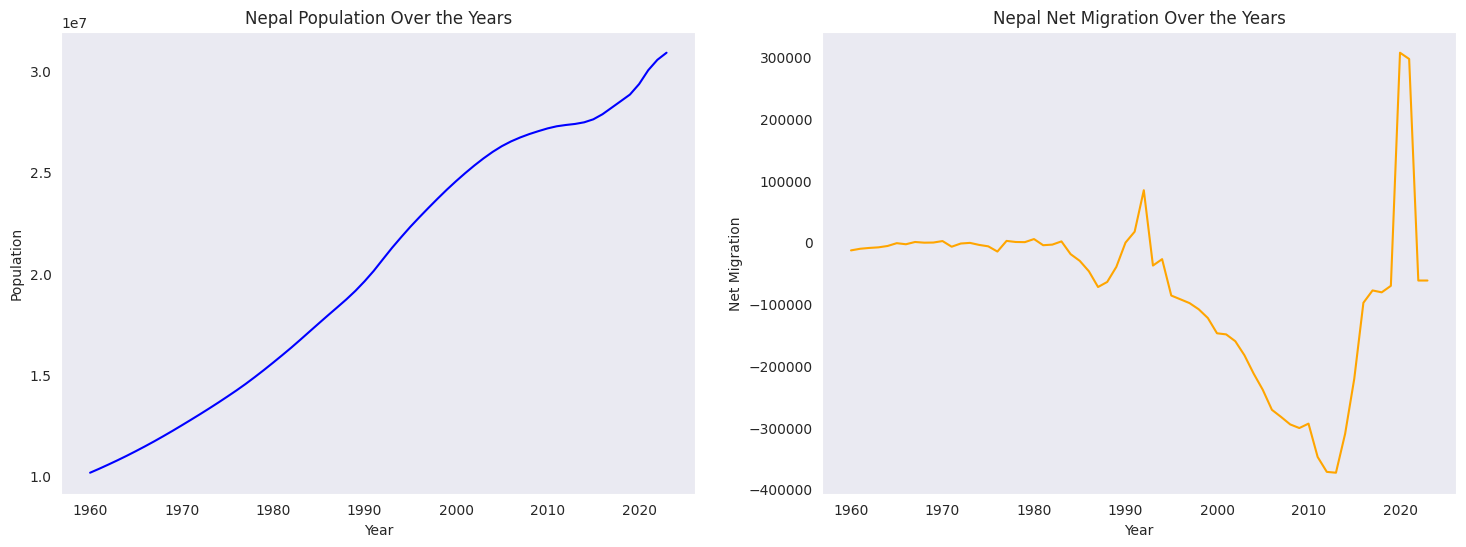

In [189]:
sns.set_style('dark')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# population over the year
sns.set_style()
sns.lineplot(data=Nepal, x='year', y='population', ax=axes[0], color='blue')
axes[0].set_title('Nepal Population Over the Years')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Population')

# Net migration over the years
sns.lineplot(data=Nepal, x='year', y='netMigration', ax=axes[1], color='orange')
axes[1].set_title('Nepal Net Migration Over the Years')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Net Migration')


In [179]:
nepala=df[df['country']=='Nepal']
nepala['population'].corr(nepala['netMigration'])

-0.46252698993238334

**A correlation of -0.46 between population and net migration in the context of Nepal suggests a moderate negative relationship. Here's what this means in the specific context:**
<span style="color:black">Interpretation of -0.46 Correlation in Nepal:
Moderate Negative Correlation: As net migration increases (more people leaving the country or fewer people coming in), the population tends to decrease, but this relationship is not strong, meaning other factors also influence population size. Conversely, when net migration decreases (fewer people leaving or more people entering), population tends to increase.background-color:magenta / font-family:newtimeroman</span>







In [180]:
ne=df[df['country']=='Nepal'].sort_values(by='year',ascending=True)
ne.sort_values(by='netMigration')

,country,year,population,netMigration,population_in_millions
7562,Nepal,2013,27381555.0,-373065.0,27
7563,Nepal,2012,27330694.0,-371708.0,27
7564,Nepal,2011,27266399.0,-347554.0,27
7561,Nepal,2014,27462106.0,-310157.0,27
7566,Nepal,2009,27026941.0,-300762.0,27
...,...,...,...,...,...
7595,Nepal,1980,15600442.0,5084.0,15
7584,Nepal,1991,20130779.0,17056.0,20
7583,Nepal,1992,20702133.0,84106.0,20
7554,Nepal,2021,30034989.0,296541.0,30


In [181]:
ne['per_pop_migrated']= (ne['netMigration']/ne['population'])*100
ne[ne['year']>1992].sort_values(by='year').head(20)

,country,year,population,netMigration,population_in_millions,per_pop_migrated
7582,Nepal,1993,21267359.0,-37782.0,21,-0.177653
7581,Nepal,1994,21794751.0,-27423.0,21,-0.125824
7580,Nepal,1995,22305571.0,-86300.0,22,-0.386899
7579,Nepal,1996,22783969.0,-92417.0,22,-0.405623
7578,Nepal,1997,23249417.0,-98574.0,23,-0.423985
7577,Nepal,1998,23703328.0,-108537.0,23,-0.457898
7576,Nepal,1999,24143157.0,-122704.0,24,-0.508235
7575,Nepal,2000,24559500.0,-147403.0,24,-0.600187
7574,Nepal,2001,24956071.0,-149185.0,24,-0.597790
7573,Nepal,2002,25332178.0,-160257.0,25,-0.632622


In [182]:
ne.sort_values(by='per_pop_migrated',ascending=False)

,country,year,population,netMigration,population_in_millions,per_pop_migrated
7555,Nepal,2020,29348627.0,306664.0,29,1.044901
7554,Nepal,2021,30034989.0,296541.0,30,0.987318
7583,Nepal,1992,20702133.0,84106.0,20,0.406267
7584,Nepal,1991,20130779.0,17056.0,20,0.084726
7595,Nepal,1980,15600442.0,5084.0,15,0.032589
...,...,...,...,...,...,...
7566,Nepal,2009,27026941.0,-300762.0,27,-1.112823
7561,Nepal,2014,27462106.0,-310157.0,27,-1.129400
7564,Nepal,2011,27266399.0,-347554.0,27,-1.274660
7563,Nepal,2012,27330694.0,-371708.0,27,-1.360039


### Nepal: Net Migration and Population Trends

- **2011-2013**: Nepal experienced significant **negative net migration** during these years, with 2013 seeing the highest outflow of **-373,065** people, which accounted for **-1.36%** of the total population. This trend reflects the growing reliance on foreign employment, as many Nepalese citizens sought work opportunities abroad.
  - **2011**: Net migration of **-347,554** (**-1.27%** of the population)
  - **2012**: Net migration of **-371,708** (**-1.36%** of the population)
  - **2013**: Net migration of **-373,065** (**-1.36%** of the population)
  - **2014**: A net migration of **-310,157** (**-1.13%** of the population) still reflected a large outflow, though slightly reduced compared to the previous years.

- **2020-2021 (Pandemic Years)**: In contrast to the earlier years of outmigration, Nepal recorded a **positive net migration** during the pandemic years. In 2020, net migration was **306,664**, which represented a **1.04%** increase in population, and in 2021, net migration was **296,541**, marking a **0.98%** increase. This change was likely influenced by the return of Nepalese migrant workers due to global economic slowdowns and travel restrictions during the COVID-19 pandemic.
  - **2020**: Net migration of **306,664** (**1.04%** of the population)
  - **2021**: Net migration of **296,541** (**0.98%** of the population)

## Summary
The data reveals a clear trend: Nepal saw a steady outflow of workers seeking employment abroad between 2011 and 2014, with 2013 marking the highest negative net migration. However, during the pandemic years of 2020 and 2021, this trend reversed as more people returned to the country, resulting in positive net migration rates.


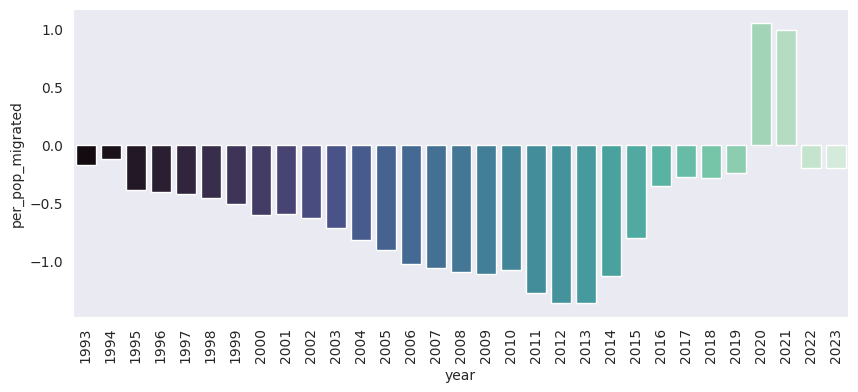

In [188]:
sns.set_style('dark')
plt.figure(figsize=(10,4))
sns.barplot(data=ne[ne['year']>1992],x='year',y='per_pop_migrated',palette='mako')
plt.xticks(rotation=90)
plt.show()


### Nepal: Net Migration Trend (1993-2012)

From 1993 to 2012, Nepal experienced a **continuous outflow of people**, with increasingly negative net migration rates each year, reflecting a growing trend of migration for foreign employment. 

- **1993-1994**: The early years of this period saw relatively smaller outflows of **-37,782** people in 1993 and **-27,423** in 1994, corresponding to **-0.18%** and **-0.13%** of the population, respectively. This marked the beginning of a trend where people gradually began to seek employment opportunities abroad.

- **1995-1999**: The negative net migration rate accelerated, with notable increases in the outflow of people. In 1995, **-86,300** people left Nepal, and by 1999, the net migration had worsened to **-122,704** people, which accounted for **-0.51%** of the population. During these years, migration abroad for labor, particularly to Gulf countries and Southeast Asia, became increasingly common.

- **2000-2005**: The outmigration trend continued to worsen. In 2000, **-147,403** people left the country, representing **-0.60%** of the population, and by 2005, the outflow had increased to **-238,799** people (**-0.91%** of the population). This rise in migration correlated with worsening economic conditions in Nepal and the growing demand for laborers abroad.

- **2006-2012**: The outflow of people reached its peak during this period, with the highest negative migration rates observed. By 2006, **-271,254** people had migrated abroad (**-1.02%** of the population), and in 2012, Nepal recorded a net migration of **-371,708** people, representing **-1.36%** of the total population. The trend during these years reflects the widespread participation of Nepalese workers in the global labor market, particularly in countries like Qatar, Saudi Arabia, and Malaysia.

### Key Insights:
- The data from 1993 to 2012 shows a **steady increase in outmigration**, with the trend peaking in the early 2010s.
- Economic factors, lack of local employment opportunities, and increased demand for foreign labor played significant roles in driving this migration.
- By the end of this period, Nepal had one of the highest outmigration rates, with more than **1%** of its population leaving the country annually for work abroad.

This long-term trend highlights the importance of foreign employment as a means of livelihood for many Nepalese families, despite the negative impact on the country's population growth.


In [184]:
df1= df
df1['per_population']=(df1['netMigration']/df1['population'])*100
df1

,country,year,population,netMigration,population_in_millions,per_population
0,Afghanistan,2023,42239854.0,-65846.0,42,-0.155886
1,Afghanistan,2022,41128771.0,-65846.0,41,-0.160097
2,Afghanistan,2021,40099462.0,-183672.0,40,-0.458041
3,Afghanistan,2020,38972230.0,166821.0,38,0.428051
4,Afghanistan,2019,37769499.0,-8082.0,37,-0.021398
...,...,...,...,...,...,...
11899,Zimbabwe,1964,4310332.0,-10064.0,4,-0.233485
11900,Zimbabwe,1963,4177931.0,-9369.0,4,-0.224250
11901,Zimbabwe,1962,4049778.0,-8931.0,4,-0.220531
11902,Zimbabwe,1961,3925952.0,-8582.0,3,-0.218597


# Top 3 highest net out migration and its causes


In [185]:
df1.sort_values(by='per_population',ascending=True).head(3)

,country,year,population,netMigration,population_in_millions,per_population
5857,Kuwait,1990,1674938.0,-1196051.0,1,-71.408673
6113,Liberia,1990,2209731.0,-712546.0,2,-32.245825
9117,Rwanda,1994,6732665.0,-2162873.0,6,-32.125065


## Key Findings and Causes

### Kuwait (1990)
- **Population:** 1,674,938
- **Net Migration:** -1,196,051
- **Migration Rate:** -71.41%

In 1990, Kuwait experienced a significant outflow of its population, with **over 71%** of people leaving the country. The cause of this mass migration was the **Iraqi invasion of Kuwait**, which marked the start of the Gulf War. The conflict led to widespread displacement as residents fled the violence, leading to a drastic reduction in Kuwait's population that year.

### Liberia (1990)
- **Population:** 2,209,731
- **Net Migration:** -712,546
- **Migration Rate:** -32.25%

Liberia saw **32.25%** of its population migrate out of the country in 1990. This sharp decline can be attributed to the onset of the **First Liberian Civil War**, which began in 1989. The conflict, marked by brutal violence, led to the displacement of hundreds of thousands of people, many of whom sought refuge in neighboring countries to escape the war.

### Rwanda (1994)
- **Population:** 6,732,665
- **Net Migration:** -2,162,873
- **Migration Rate:** -32.13%

In 1994, Rwanda experienced a net migration of over **2 million** people, amounting to a **32.13%** reduction in its population. This mass exodus was caused by the **Rwandan Genocide**, a horrific event during which hundreds of thousands were killed, and millions fled the country. Refugees sought safety in neighboring countries as the violence escalated, leaving a profound demographic impact on Rwanda.

## Conclusion
This analysis demonstrates the profound effects of wars and conflicts on migration patterns. In countries like Kuwait, Liberia, and Rwanda, major crises led to a significant portion of the population fleeing for safety. These events not only reshaped the demographics of each country but also highlighted the severe consequences of political instability on human migration.

In [186]:
df1.sort_values(by='per_population',ascending=False).head(3)

,country,year,population,netMigration,population_in_millions,per_population
5856,Kuwait,1991,1339500.0,460628.0,1,34.388055
5999,Lebanon,1976,3070419.0,700005.0,3,22.798354
9115,Rwanda,1996,6715510.0,1372202.0,6,20.433325



## Additional Key Findings and Causes

### Kuwait (1991)
- **Population:** 1,339,500
- **Net Migration:** 460,628
- **Migration Rate:** 34.39%

In 1991, Kuwait experienced a net migration **inflow** of **460,628** people, corresponding to a **34.39%** increase in population. This increase occurred after the end of the **Gulf War**, when Kuwait was liberated from Iraqi occupation. Many citizens and expatriates who had fled during the Iraqi invasion returned to Kuwait, contributing to the significant population recovery.

### Lebanon (1976)
- **Population:** 3,070,419
- **Net Migration:** 700,005
- **Migration Rate:** 22.80%

Lebanon experienced a net migration inflow of **700,005** people in 1976, resulting in a **22.80%** population increase. This influx was related to the early years of the **Lebanese Civil War**, which began in 1975. While the war caused many people to leave, certain areas saw refugee movements and temporary returns of displaced people, which may explain the population increase in specific regions.

### Rwanda (1996)
- **Population:** 6,715,510
- **Net Migration:** 1,372,202
- **Migration Rate:** 20.43%

Rwanda saw a net migration inflow of **1,372,202** people in 1996, representing a **20.43%** increase in population. This was part of the **post-genocide return** of refugees who had fled during the 1994 Rwandan Genocide. By 1996, many Rwandans were returning home from refugee camps in neighboring countries as the situation in Rwanda began to stabilize.



## Conclusion

This analysis highlights how global events like wars, economic conditions, and political instability influence migration patterns. For example, the **war in Ukraine** has caused a significant outflow of people seeking refuge in neighboring countries, demonstrating how conflicts can lead to large-scale displacement. 

In **Nepal**, foreign employment and education have been major factors driving migration, with many Nepali workers seeking opportunities abroad, particularly in the **Gulf countries** and **Southeast Asia**, due to limited local prospects. The desire for better education has also contributed to the steady outflow of young people.

The **pandemic years** (2020-2021) saw a temporary shift in migration trends, with some countries experiencing positive net migration as workers returned home due to travel restrictions and economic disruptions.

Overall, migration is shaped by a mix of personal aspirations and external events like wars, economic shifts, and crises. In Nepal, these factors have combined to significantly influence the country’s migration trends, with far-reaching implications for its workforce and economy.
